In [36]:
import cv2
import matplotlib.pyplot as plt
import math
import numpy as np
from skimage.exposure import match_histograms
# các cell để có thể run độc lập với python version / virtual env khác nhau

In [ ]:

# Đọc ảnh màu
image = cv2.imread('imgs\\dark_forest.jpg')

# Chuyển BGR → HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Lấy kênh V
h, s, v = cv2.split(hsv)

# Cân bằng histogram trên kênh V
v_eq = cv2.equalizeHist(v)



# Gộp lại thành ảnh HSV mới
hsv_eq = cv2.merge((h, s, v_eq))

# Chuyển HSV → BGR để hiển thị
result = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2BGR)

# Hiển thị kết quả
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Cân bằng histogram (HSV - kênh V)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
img_rgb =  cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Đổi kiểu dữ liệu sang float để tránh tràn số
img_float = img_rgb.astype(np.float32)
c = 1.2
img_log = c * np.log1p(img_float)  # log(1 + r)
# Chuẩn hóa về [0, 255]
img_log = np.clip(img_log / img_log.max() * 255, 0, 255).astype(np.uint8)

# Hiển thị
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_log)
plt.title("Sau log transform")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
reference = cv2.imread('imgs\\style_blue.jpg')
reference_rgb = cv2.cvtColor(reference, cv2.COLOR_BGR2RGB)
matched = match_histograms(img_rgb, reference_rgb, channel_axis=-1)



# plt.imshow(matched)
# plt.title("Ảnh forest log style blue")
# plt.axis("off")  # Ẩn trục tọa độ
# plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(matched)
plt.title("Sau log transform")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

# Đọc ảnh
img_1 = cv2.imread('imgs\\vintage.jpg')
img_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
h, w = img_1.shape[:2]

# Tạo lưới tọa độ ảnh
x, y = np.meshgrid(np.arange(w), np.arange(h))

# Các hệ số đa thức đơn giản (ví dụ minh họa)

# distorted
# x_new = x_coords + 0.0002 * x_coords**2 + 0.0002 * y_coords**2
# y_new = y_coords + 0.0002 * x_coords**2 - 0.0002 * y_coords**2

#xoẵn ảnh
# Tọa độ tâm ảnh
cx, cy = w / 2, h / 2

# Tính khoảng cách và góc từ tâm
x_shifted = x - cx
y_shifted = y - cy
radius = np.sqrt(x_shifted**2 + y_shifted**2)
angle = np.arctan2(y_shifted, x_shifted)

# Cường độ xoắn: tăng hệ số để rõ hơn
strength = 0.002  # càng lớn càng xoắn
angle_new = angle + strength * radius

# Tính lại tọa độ mới
x_new = cx + radius * np.cos(angle_new)
y_new = cy + radius * np.sin(angle_new)

# Cắt vùng ảnh hợp lệ
x_new = np.clip(x_new, 0, w - 1).astype(np.float32)
y_new = np.clip(y_new, 0, h - 1).astype(np.float32)

# Nội suy ảnh mới
twisted = cv2.remap(img_1, x_new, y_new, interpolation=cv2.INTER_LINEAR)


# Dùng remap để nội suy pixel tại vị trí mới
distorted = cv2.remap(img_1, x_new, y_new, interpolation=cv2.INTER_LINEAR)

# Hiển thị ảnh kết quả
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_1)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(twisted)
plt.title("Biến dạng đa thức (m=2)")
plt.axis("off")

plt.tight_layout()
plt.show()

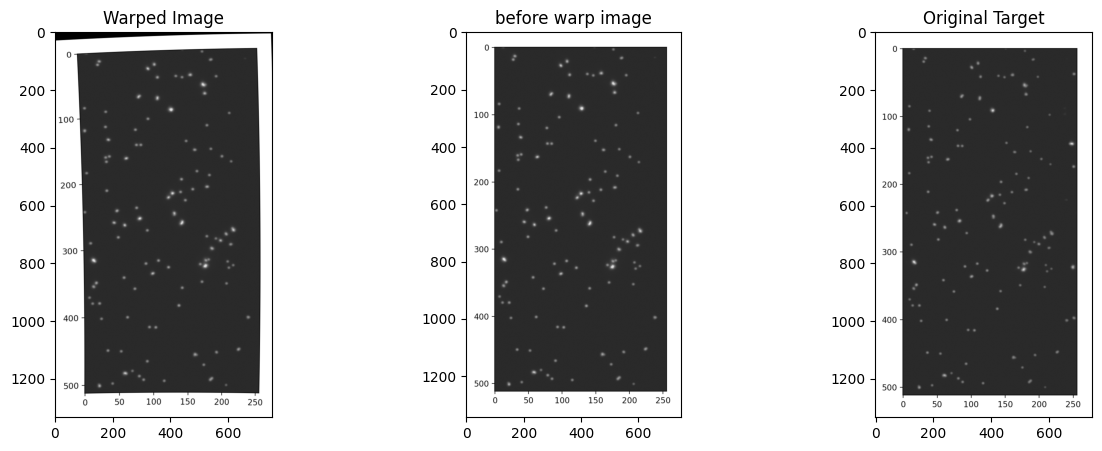

In [ ]:
from skimage import transform, feature, color, io
from skimage.measure import ransac
import matplotlib.pyplot as plt

#CONG DUNG 1: để lại ghép các ảnh overlap thành 1 ảnh duy nhất 
#CONG DUNG 2: 

# Load grayscale images
img1 = color.rgb2gray(io.imread('imgs\\channel1.png')[..., :3])
img2 = color.rgb2gray(io.imread('imgs\\channel2.png')[..., :3])

# Detect ORB keypoints
orb = feature.ORB(n_keypoints=500)
orb.detect_and_extract(img1)
keypoints1 = orb.keypoints
descriptors1 = orb.descriptors

orb.detect_and_extract(img2)
keypoints2 = orb.keypoints
descriptors2 = orb.descriptors

# Match descriptors
matches12 = feature.match_descriptors(
    descriptors1, descriptors2, cross_check=True)

# Get coordinates of matched keypoints
src = keypoints2[matches12[:, 1]]  # source: img2
dst = keypoints1[matches12[:, 0]]  # destination: img1

# Estimate forward transformation (img2 -> img1)
model_robust, inliers = ransac((src, dst),
                               transform.PolynomialTransform,
                               min_samples=10,
                               residual_threshold=2,
                               max_trials=100)

# To get the inverse transformation (img1 -> img2), swap src and dst
model_robust_inverse, inliers_inverse = ransac((dst, src),
                                               transform.PolynomialTransform,
                                               min_samples=10,
                                               residual_threshold=2,
                                               max_trials=100)

# Apply transform to warp img2 to match img1

warped = transform.warp(img2, model_robust, output_shape=img1.shape)    

# Show result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Warped Image")
plt.imshow(warped, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("before warp image")
plt.imshow(img2, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("Original Target")
plt.imshow(img1, cmap='gray')
plt.show()

w 150 h 150 chan 3
w" 1350 h" 1350


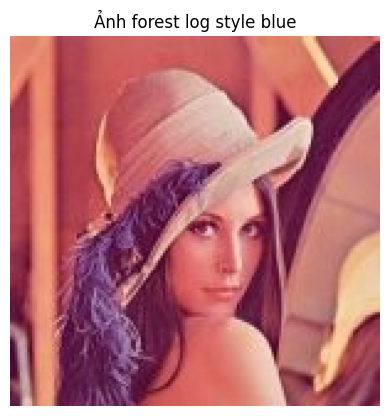

In [63]:
lena_rgb = cv2.cvtColor(cv2.imread('imgs\\lena.jpg'), cv2.COLOR_BGR2RGB)
width, height, channel = lena_rgb.shape

#scale_maxtrix = [[2,0,0],[0,2,0],[0,0,1]]
print('w', width, 'h', height, 'chan', channel)
scale = 9.0
scaled_img = transform.resize(
    lena_rgb, 
    output_shape=(
    scale*height, scale*width), 
    #mode='constant', 
    order=0, # ap dụng Linear interpolation, 0 ap dung nearest interpoltion
    anti_aliasing=False, #ap dung guass truoc khi scale 
    preserve_range=True,
    
)

scaled_img = scaled_img.astype('uint8')
print('w"',scaled_img.shape[0] ,'h"', scaled_img.shape[1])
# Hiển thị kết quả

plt.imshow(scaled_img)
plt.title("Ảnh forest log style blue")
plt.axis("off")  # Ẩn trục tọa độ
plt.show()